# pass@k Scaling Profiles

Goal: analyze how pass@k scales with k at different training stages.

Expected takeaway: which methods scale better as k increases and whether the curves are concave or saturating.


In [41]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

DATA_DIR_CANDIDATES = [
    Path.cwd() / "final_results" / "data",
    Path.cwd().parent / "final_results" / "data",
    Path.cwd() / "data",
    Path.cwd().parents[1] / "final_results" / "data",
    Path(__file__).resolve().parents[1] / "data" if '__file__' in globals() else Path.cwd() / "final_results" / "data",
]

# Robust data path resolver (works when running from repo root or final_results/tools)

# Robust data path resolver (works when running from repo root or final_results/tools)

def resolve_data_path(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "final_results" / "data" / filename,
        cwd / "data" / filename,
    ]
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data" / filename)
        candidates.append(parent / "data" / filename)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in candidates: {candidates}")




combined_path = resolve_data_path("combined_wide.csv")
combined = pd.read_csv(combined_path)
combined = combined.drop(columns=[c for c in combined.columns if c.lower().startswith("unnamed")], errors="ignore")
combined["Step"] = pd.to_numeric(combined["Step"], errors="coerce")

metric_cols = ["avg@32", "pass@1", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]
for c in metric_cols:
    combined[c] = pd.to_numeric(combined[c], errors="coerce")

passk_cols = [c for c in metric_cols if c.startswith("pass@")]
passk_ks = [int(c.split("@")[1]) for c in passk_cols]

final_step = int(combined["Step"].max())

# Aggregate across seeds for smoother curves
agg = combined.groupby(["Step", "algorithm"], as_index=False)[metric_cols].mean()

# Helpers
PLOT_COUNTER = 0

def new_fig(title: str):
    global PLOT_COUNTER
    PLOT_COUNTER += 1
    plt.figure()
    plt.title(title)


In [42]:
# Build a tidy table of pass@k values at selected steps
unique_steps = sorted(combined["Step"].dropna().unique())
if len(unique_steps) >= 3:
    step_choices = [unique_steps[0], unique_steps[len(unique_steps)//2], unique_steps[-1]]
elif len(unique_steps) == 2:
    step_choices = [unique_steps[0], unique_steps[1]]
else:
    step_choices = unique_steps

long_rows = []
for step in step_choices:
    sub = agg[agg["Step"] == step]
    for _, row in sub.iterrows():
        for col, k in zip(passk_cols, passk_ks):
            long_rows.append({"algorithm": row["algorithm"], "Step": step, "k": k, "passk": row[col]})

passk_long = pd.DataFrame(long_rows)


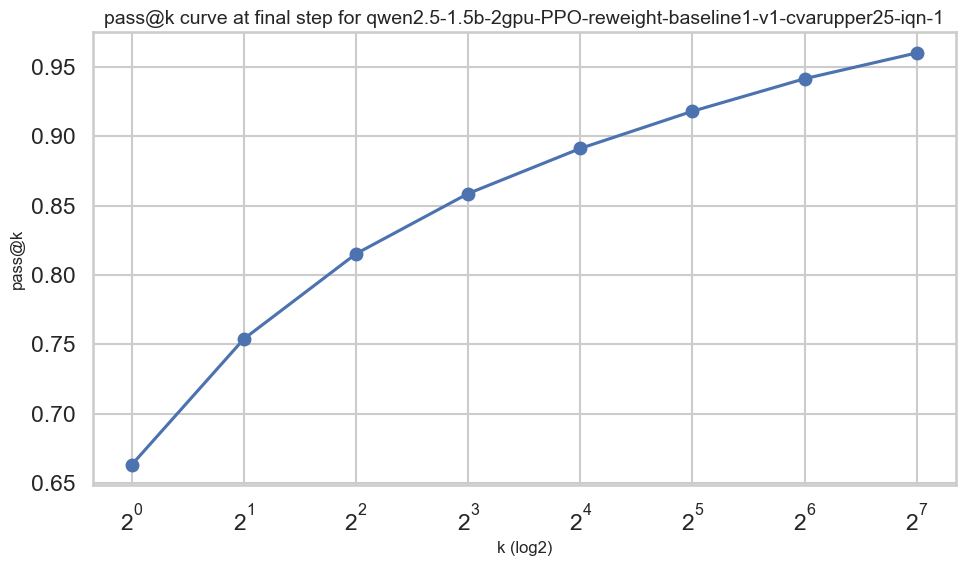

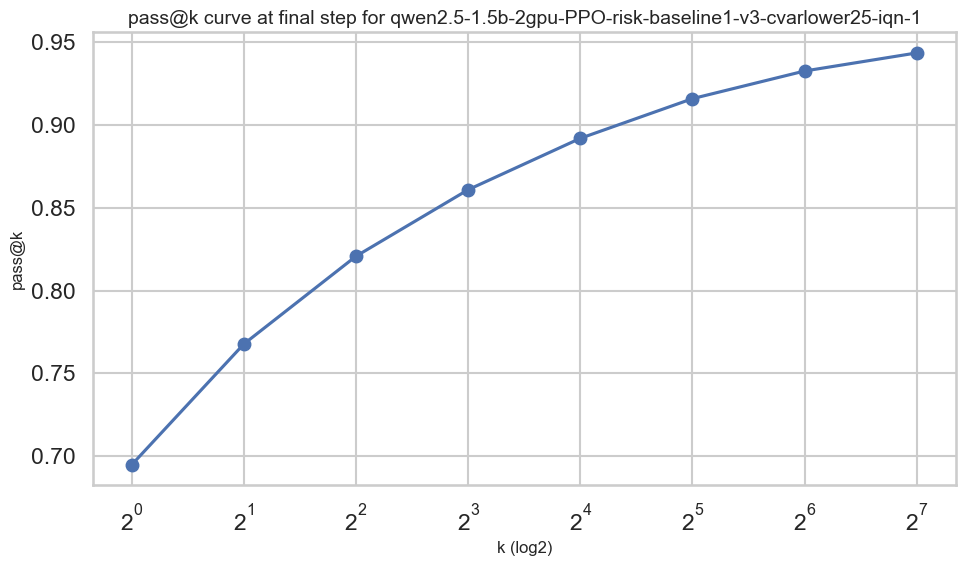

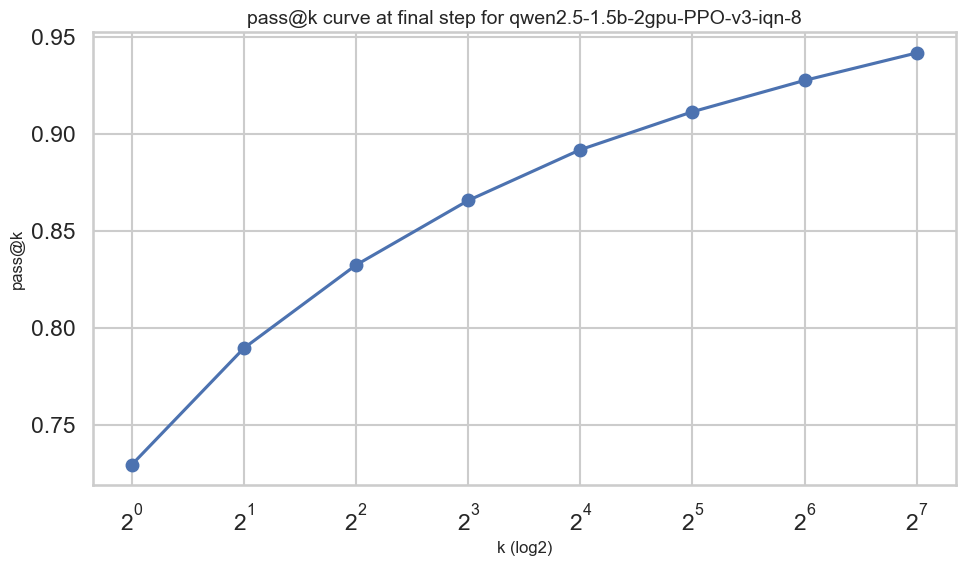

In [43]:
# Plot 1: per-algorithm pass@k curve at final step
final_passk = passk_long[passk_long["Step"] == final_step]
for algo in sorted(final_passk["algorithm"].unique()):
    sub = final_passk[final_passk["algorithm"] == algo]
    new_fig(f"pass@k curve at final step for {algo}")
    plt.plot(sub["k"], sub["passk"], marker="o")
    plt.xscale("log", base=2)
    plt.xlabel("k (log2)")
    plt.ylabel("pass@k")
    plt.tight_layout()
    plt.show()


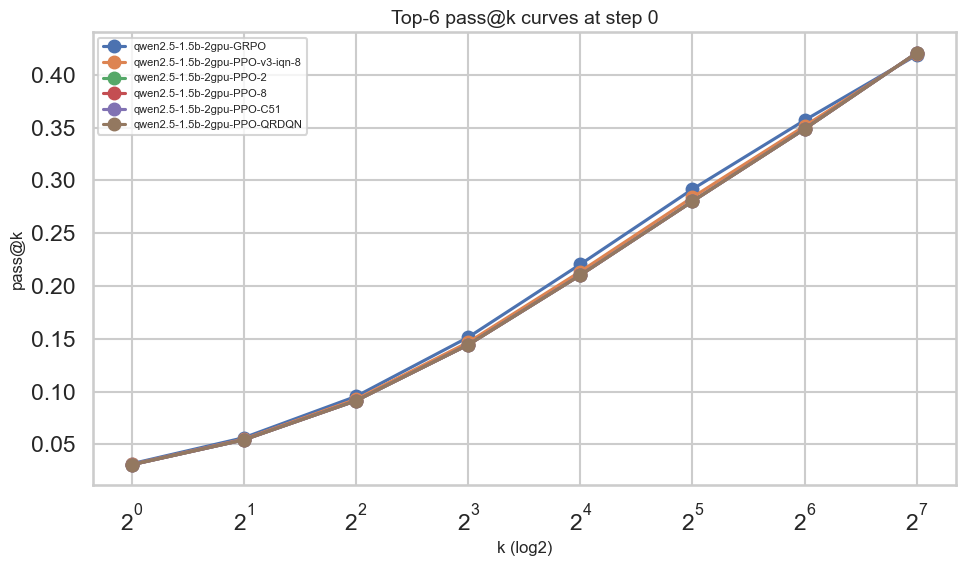

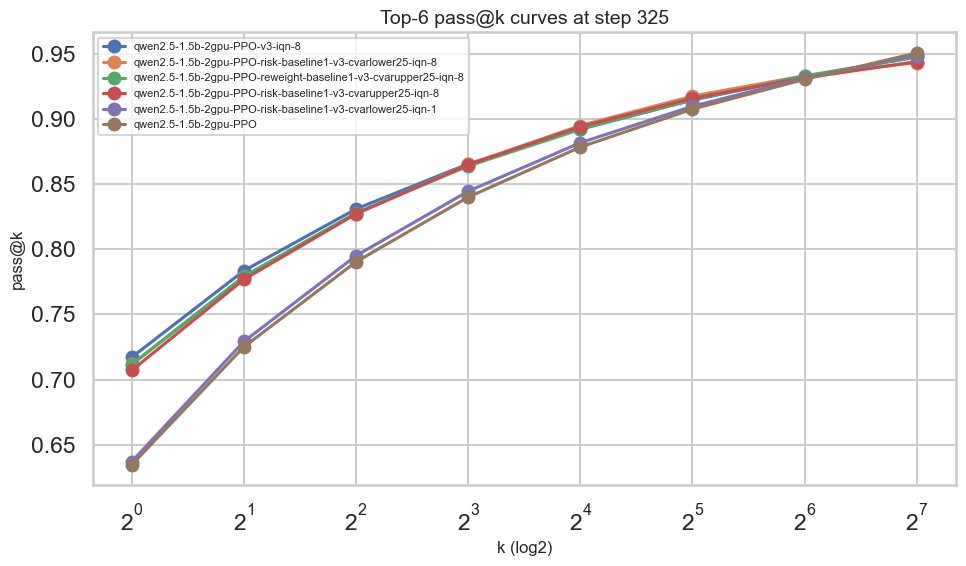

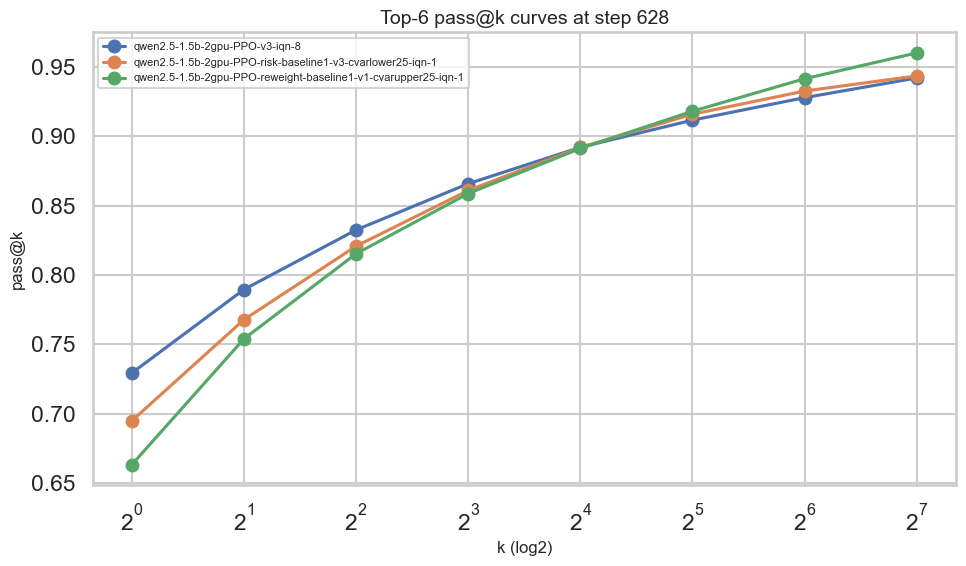

In [44]:
# Plot 2: top-6 overlayed curves for early/mid/final steps
for step in step_choices:
    sub = passk_long[passk_long["Step"] == step]
    ranking = agg[agg["Step"] == step].sort_values("pass@1", ascending=False)
    tops = ranking["algorithm"].head(6).tolist()
    new_fig(f"Top-6 pass@k curves at step {step}")
    for algo in tops:
        s = sub[sub["algorithm"] == algo]
        plt.plot(s["k"], s["passk"], marker="o", label=algo)
    plt.xscale("log", base=2)
    plt.xlabel("k (log2)")
    plt.ylabel("pass@k")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


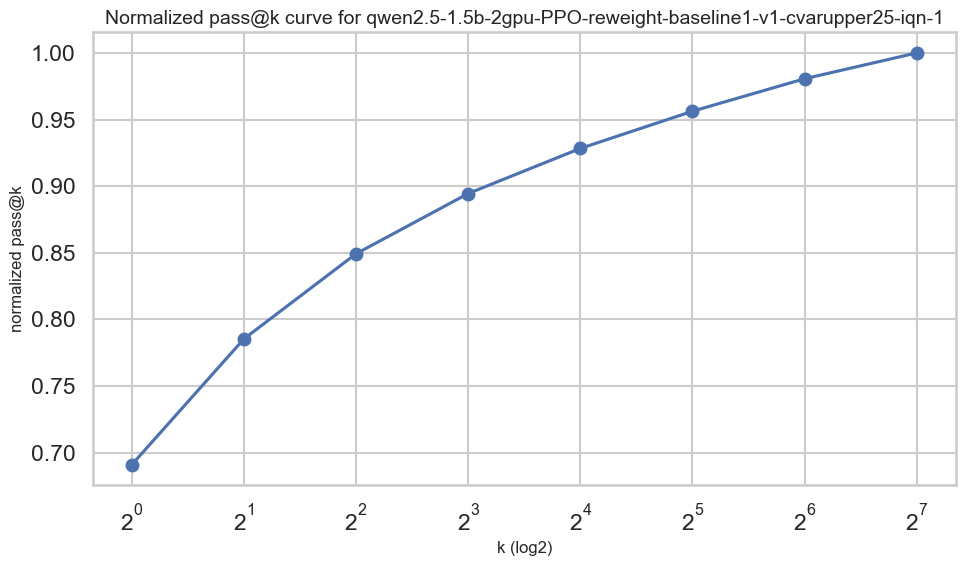

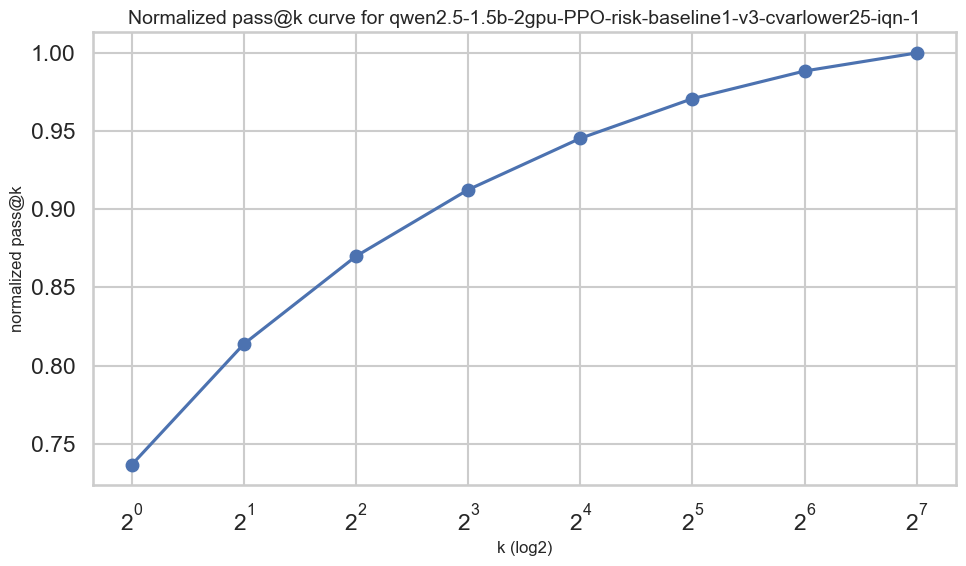

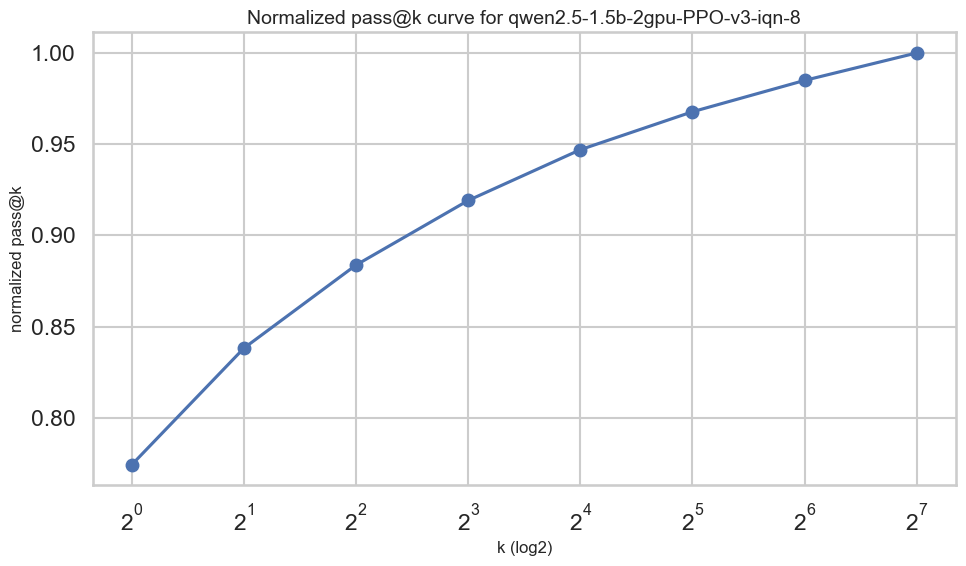

Generated 9 figures


In [45]:
# Plot 3: normalized pass@k curves at final step
for algo in sorted(final_passk["algorithm"].unique()):
    sub = final_passk[final_passk["algorithm"] == algo].copy()
    sub["norm"] = sub["passk"] / sub["passk"].max()
    new_fig(f"Normalized pass@k curve for {algo}")
    plt.plot(sub["k"], sub["norm"], marker="o")
    plt.xscale("log", base=2)
    plt.xlabel("k (log2)")
    plt.ylabel("normalized pass@k")
    plt.tight_layout()
    plt.show()

print(f"Generated {PLOT_COUNTER} figures")


In [46]:
# Additional derived metrics for richer k-axis analysis
passk_long = passk_long.sort_values(["Step", "algorithm", "k"]).reset_index(drop=True)
passk_long["log2k"] = np.log2(passk_long["k"])

# Normalized within each (Step, algorithm) so curves are comparable
passk_long["norm"] = passk_long.groupby(["Step", "algorithm"])["passk"].transform(lambda x: x / x.max())

# Lift vs pass@1 within each group (assumes k sorted)
def _lift_vs_pass1(group):
    base = group["passk"].iloc[0]
    if pd.isna(base) or base == 0:
        return group["passk"] * np.nan
    return group["passk"] / base

passk_long["lift_vs_pass1"] = passk_long.groupby(["Step", "algorithm"], group_keys=False).apply(_lift_vs_pass1)

# Marginal gain when doubling k (delta pass@k)
passk_long["delta_passk"] = passk_long.groupby(["Step", "algorithm"])["passk"].diff()

# Per-group AUC in log2(k) space and saturation k@90%
summary_rows = []
for (step, algo), sub in passk_long.groupby(["Step", "algorithm"]):
    s = sub.sort_values("k")
    if s["passk"].notna().sum() >= 2:
        auc = np.trapz(s["passk"], s["log2k"])
    else:
        auc = np.nan
    maxv = s["passk"].max()
    k90 = s.loc[s["passk"] >= 0.9 * maxv, "k"].min() if pd.notna(maxv) else np.nan
    summary_rows.append({"Step": step, "algorithm": algo, "auc_log2k": auc, "k90": k90})

summary_metrics = pd.DataFrame(summary_rows)
summary_final = summary_metrics[summary_metrics["Step"] == final_step].sort_values("auc_log2k", ascending=False)


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94258/2488406964.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(s["passk"], s["log2k"])


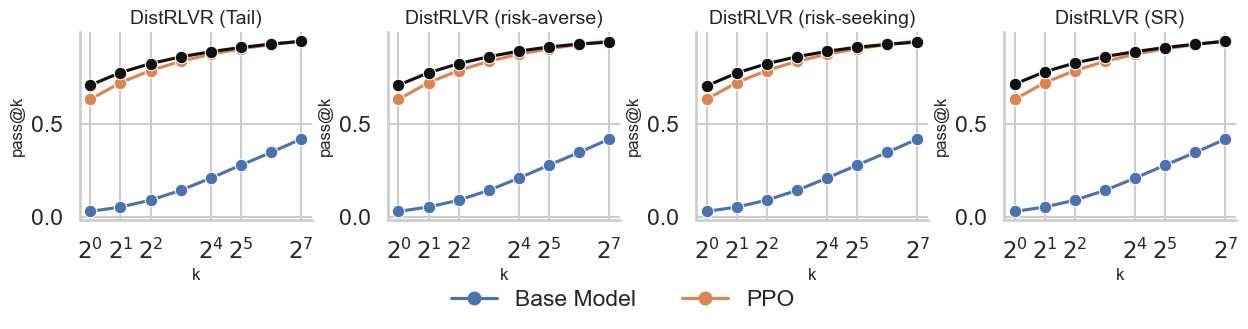

In [53]:
# Plot 4: per-algorithm curves with PPO baselines (step0/step325)
# Each facet shows: PPO@0 and PPO@325, plus the algo curve at step325
ppo_step0 = 0
ppo_step325 = 325

# Pick PPO baseline algorithm name from data
algos = sorted(passk_long["algorithm"].unique())
ppo_candidates = [a for a in algos if a.endswith("-PPO")]
if ppo_candidates:
    ppo_name = ppo_candidates[0]
else:
    ppo_candidates = [a for a in algos if "PPO" in a]
    ppo_name = ppo_candidates[0] if ppo_candidates else algos[0]

# Keep only selected facets (by name)
selected_algos = [
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-v3-iqn-8",
]
facet_algos = [a for a in selected_algos if a in algos]

facet_title_map = {
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-8": "DistRLVR (Tail)",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-8": "DistRLVR (risk-averse)",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-8": "DistRLVR (risk-seeking)",
    "qwen2.5-1.5b-2gpu-PPO-v3-iqn-8": "DistRLVR (SR)",
}

label_map = {
    f"{ppo_name}@{ppo_step0}": "Base Model",
    f"{ppo_name}@{ppo_step325}": "PPO",
}

rows = []
for algo in facet_algos:
    # target algo curve at step325
    s = passk_long[(passk_long["algorithm"] == algo) & (passk_long["Step"] == ppo_step325)]
    if not s.empty:
        tmp = s.copy()
        tmp["facet_algo"] = algo
        tmp["kind"] = "algo"
        rows.append(tmp)
    # PPO baselines duplicated into each facet
    for step in [ppo_step0, ppo_step325]:
        b = passk_long[(passk_long["algorithm"] == ppo_name) & (passk_long["Step"] == step)]
        if not b.empty:
            tmp = b.copy()
            tmp["facet_algo"] = algo
            tmp["label"] = f"{ppo_name}@{step}"
            tmp["kind"] = "ppo"
            rows.append(tmp)

overlay = pd.concat(rows, ignore_index=True) if rows else passk_long.iloc[0:0].copy()

# Ensure required columns exist even when overlay is empty
if "facet_algo" not in overlay.columns:
    if "algorithm" in overlay.columns:
        overlay["facet_algo"] = overlay["algorithm"]
    else:
        overlay["facet_algo"] = pd.Series(dtype="object")
if "label" not in overlay.columns:
    if {"algorithm", "Step"}.issubset(overlay.columns):
        overlay["label"] = overlay["algorithm"].astype(str) + "@" + overlay["Step"].astype(str)
    else:
        overlay["label"] = pd.Series(dtype="object")
if "kind" not in overlay.columns:
    overlay["kind"] = pd.Series(dtype="object")

# Keep numeric columns typed when empty
if "k" not in overlay.columns:
    overlay["k"] = pd.Series(dtype="float")
if "passk" not in overlay.columns:
    overlay["passk"] = pd.Series(dtype="float")

algo_rows = overlay[overlay["kind"] == "algo"].copy()
ppo_rows = overlay[overlay["kind"] == "ppo"].copy()
ppo_rows["label"] = ppo_rows["label"].map(label_map)
ppo_rows = ppo_rows[ppo_rows["label"].isin(["Base Model", "PPO"])].copy()

# Palette to keep legend colors consistent
base_color, ppo_color = sns.color_palette("deep", 2)
palette = {"Base Model": base_color, "PPO": ppo_color}

# Draw PPO baselines first, then overlay the algo curve on top
# Initialize grid with PPO

g = sns.relplot(
    data=ppo_rows,
    x="k", y="passk", hue="label", col="facet_algo",
    kind="line", marker="o", col_wrap=4, height=3.2, facet_kws={"sharey": False},
    palette=palette, hue_order=["Base Model", "PPO"], legend=False
)

# Overlay algo curve on top and set titles
for ax, facet in zip(g.axes.flat, g.col_names):
    sub_algo = algo_rows[algo_rows["facet_algo"] == facet]
    if not sub_algo.empty:
        sns.lineplot(
            data=sub_algo, x="k", y="passk",
            marker="o", ax=ax, color="#111111", zorder=5
        )
    ax.set_title(facet_title_map.get(facet, facet))
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Use log2 scale and label ticks as 2^n (sparse)
for ax in g.axes.flat:
    try:
        ax.set_xscale("log", base=2)
    except TypeError:
        ax.set_xscale("log", basex=2)

if not overlay.empty:
    import numpy as np
    ticks = sorted([t for t in overlay["k"].dropna().unique() if t > 0])
    if ticks:
        # keep only powers of 2
        pow2 = [t for t in ticks if abs(np.log2(t) - round(np.log2(t))) < 1e-6]
        # reduce density: keep up to 6 evenly spaced powers
        if len(pow2) > 6:
            idx = np.linspace(0, len(pow2) - 1, 6, dtype=int)
            pow2 = [pow2[i] for i in idx]
        def _tick_label(v):
            n = np.log2(v)
            return rf"$2^{{{int(round(n))}}}$"
        tick_labels = [_tick_label(t) for t in pow2]
        for ax in g.axes.flat:
            ax.set_xticks(pow2)
            ax.set_xticklabels(tick_labels)

# Bottom legend (horizontal)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=palette["Base Model"], marker="o", label="Base Model"),
    Line2D([0], [0], color=palette["PPO"], marker="o", label="PPO"),
]

g.fig.legend(
    legend_handles, ["Base Model", "PPO"], title="",
    loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False
)

g.set(xlabel="k", ylabel="pass@k")

g.fig.savefig("final_results/figs/plot4_dist_rlvr.pdf", bbox_inches="tight")
plt.show()


ValueError: Could not interpret value `_hue` for `hue`. An entry with this name does not appear in `data`.

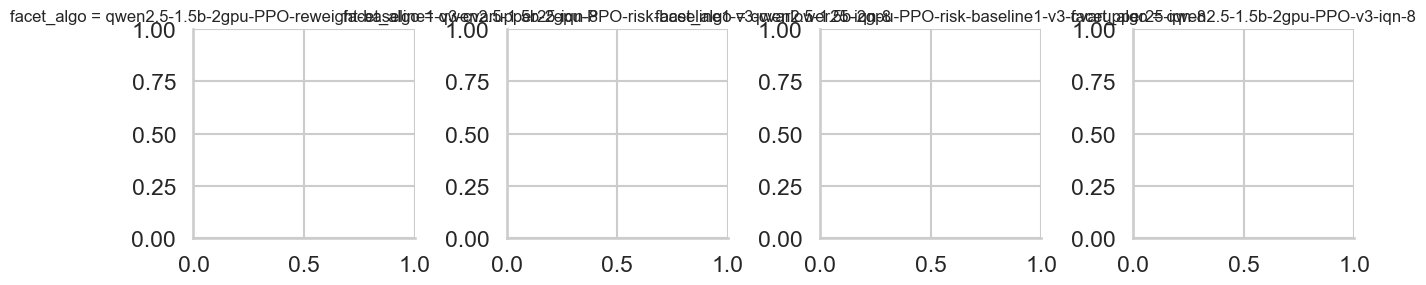

In [48]:
# Plot 4c: filter out labels containing 'v1' or '-1'
# Ensure overlay has facet column even if previous cell wasn't run
if "overlay" not in globals():
    raise RuntimeError("Run the Plot 4 cell first to build `overlay`.")

filtered = overlay.copy()

# Guarantee facet/label columns exist even if upstream was modified
if "facet_algo" not in filtered.columns:
    if "algorithm" in filtered.columns:
        filtered["facet_algo"] = filtered["algorithm"]
    else:
        filtered["facet_algo"] = "unknown"

if "label" not in filtered.columns:
    if {"algorithm", "Step"}.issubset(filtered.columns):
        filtered["label"] = filtered["algorithm"].astype(str) + "@" + filtered["Step"].astype(str)
    else:
        filtered["label"] = "unknown"

filtered = filtered[~filtered["label"].str.contains("v1", na=False)]
filtered = filtered[~filtered["label"].str.contains("-1", na=False)]

g = sns.relplot(
    data=filtered,
    x="k", y="passk", hue="label", col="facet_algo",
    kind="line", marker="o", col_wrap=4, height=3.2, facet_kws={"sharey": False}
)
g.set(xscale="log", xlabel="k (log2)", ylabel="pass@k")
g.fig.suptitle("Per-algorithm pass@k vs PPO baselines (filtered labels)", y=1.02)
plt.show()



In [ ]:
# 删除 label 中包含 "v1" 或 "-1" 的行（基于上一个 cell 的 overlay / overlay_ppo）
pattern = r"v1|-1"

overlay_clean = overlay[~overlay["label"].str.contains(pattern, na=False)].reset_index(drop=True)
overlay_ppo_clean = overlay_ppo[~overlay_ppo["label"].str.contains(pattern, na=False)].reset_index(drop=True)

print(f"overlay: {len(overlay)} -> {len(overlay_clean)} rows")
print(f"overlay_ppo: {len(overlay_ppo)} -> {len(overlay_ppo_clean)} rows")

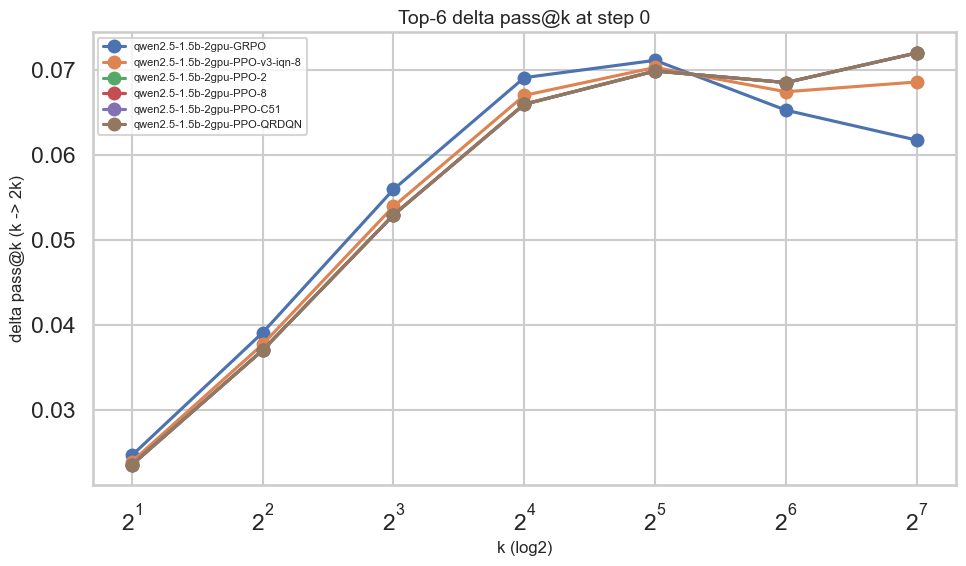

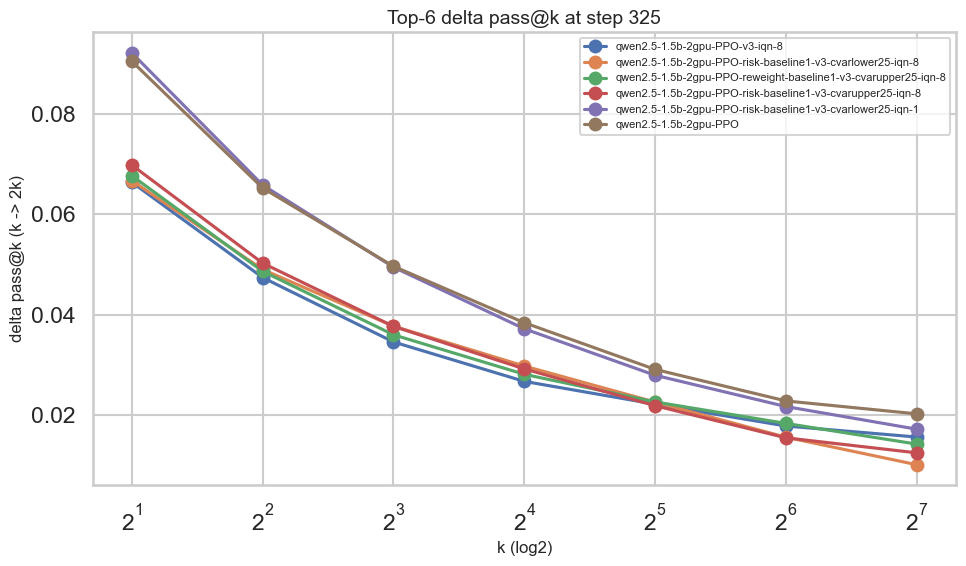

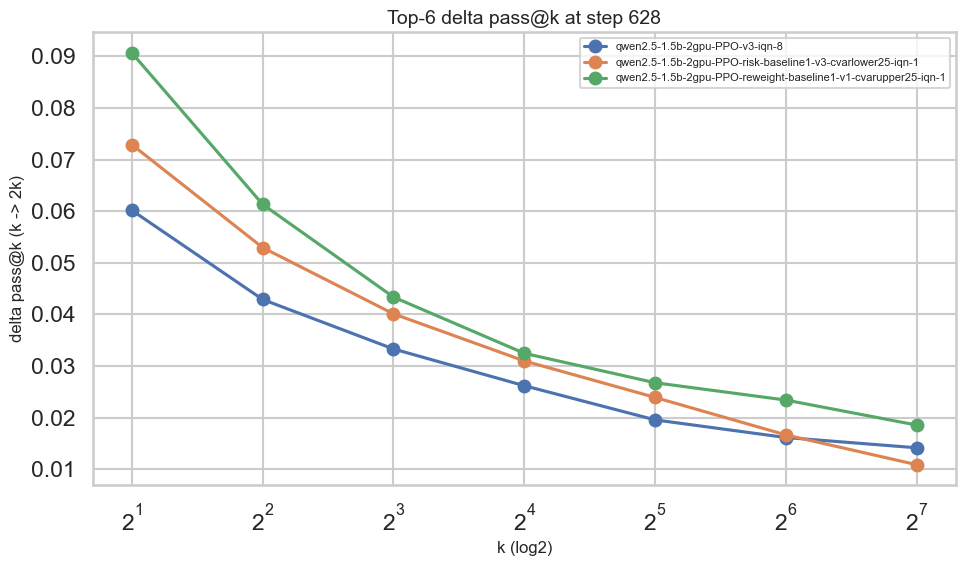

In [ ]:
# Plot 5: marginal gains when doubling k (delta pass@k)
for step in step_choices:
    sub = passk_long[passk_long["Step"] == step]
    ranking = agg[agg["Step"] == step].sort_values("pass@1", ascending=False)
    tops = ranking["algorithm"].head(6).tolist()
    new_fig(f"Top-6 delta pass@k at step {step}")
    for algo in tops:
        s = sub[sub["algorithm"] == algo]
        plt.plot(s["k"], s["delta_passk"], marker="o", label=algo)
    plt.xscale("log", base=2)
    plt.xlabel("k (log2)")
    plt.ylabel("delta pass@k (k -> 2k)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


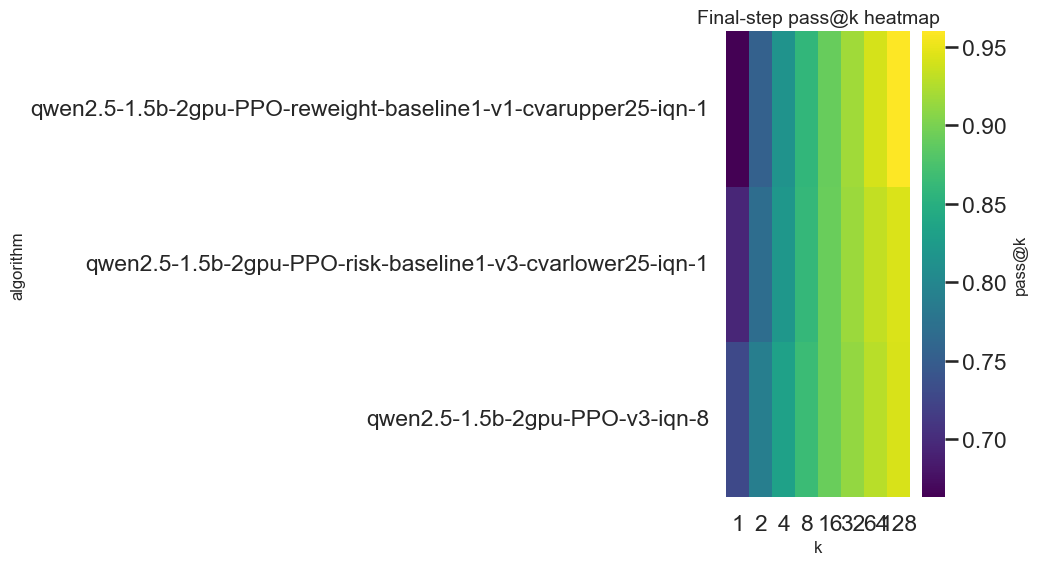

In [ ]:
# Plot 6: heatmap of pass@k at final step (algorithms vs k)
final_matrix = (final_passk
                .pivot(index="algorithm", columns="k", values="passk")
                .sort_index())
new_fig("Final-step pass@k heatmap")
sns.heatmap(final_matrix, annot=False, cmap="viridis", cbar_kws={"label": "pass@k"})
plt.xlabel("k")
plt.ylabel("algorithm")
plt.tight_layout()
plt.show()


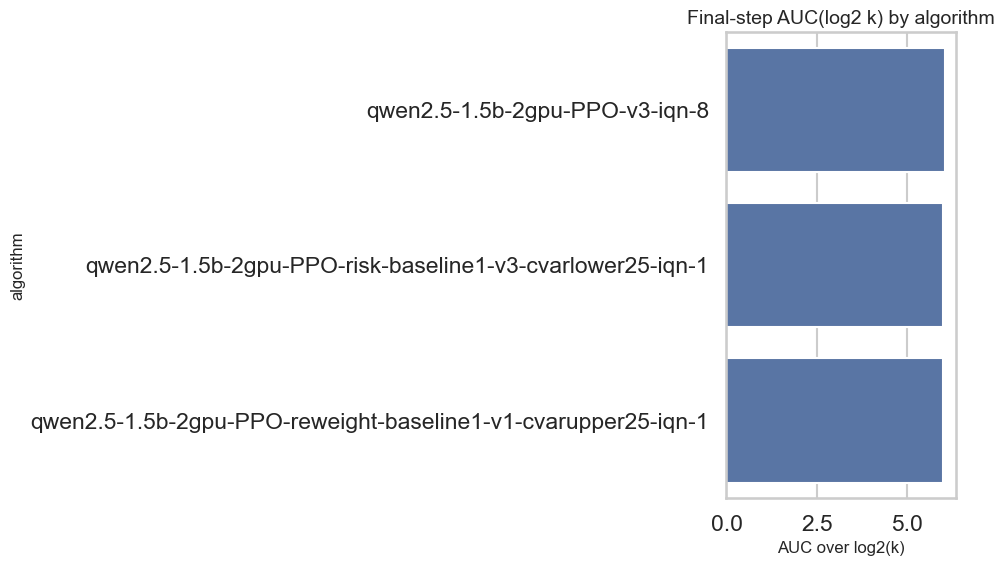

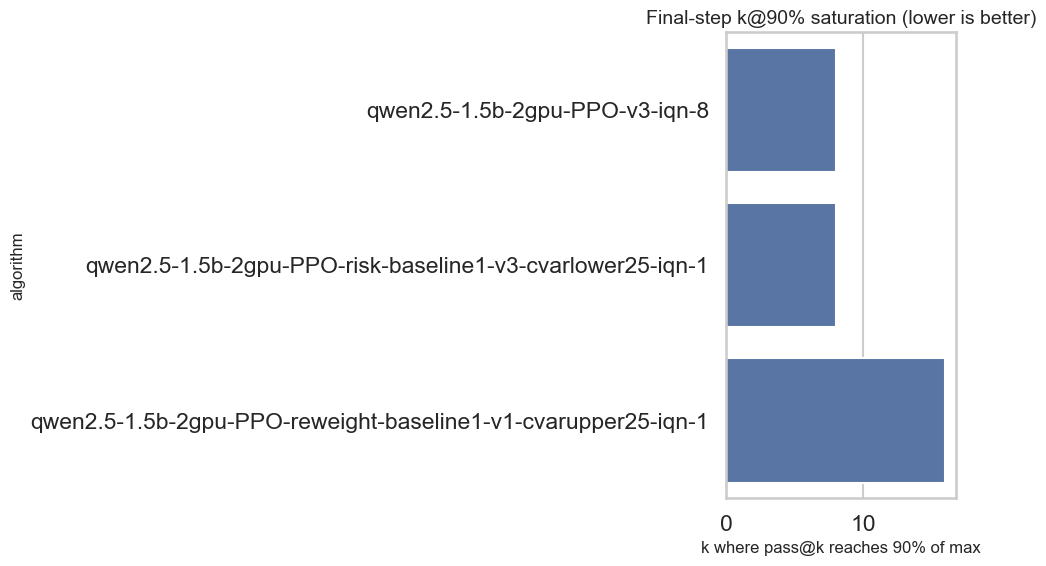

In [ ]:
# Plot 7: AUC in log2(k) space and saturation k@90% at final step
new_fig("Final-step AUC(log2 k) by algorithm")
sns.barplot(data=summary_final, y="algorithm", x="auc_log2k", orient="h")
plt.xlabel("AUC over log2(k)")
plt.ylabel("algorithm")
plt.tight_layout()
plt.show()

new_fig("Final-step k@90% saturation (lower is better)")
sns.barplot(data=summary_final.sort_values("k90"), y="algorithm", x="k90", orient="h")
plt.xlabel("k where pass@k reaches 90% of max")
plt.ylabel("algorithm")
plt.tight_layout()
plt.show()
